### Mutual Correlation Energy, Orbital Energy Decomposition

In [1]:
import forte2
import numpy as np
import mutual_correlation_energy_mod_fast as mc_mod
from plot_correlation_energy import mutual_correlation_plot

In [28]:
xyz = f"""
H 0.000 0.000 0.000
H 0.000 0.740 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   1.39839733   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.217e+00
  Min eigenvalue: 1.591e-03
  Condition number: 2.650e+03
  Inverse condition number: 3.774e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.591e-03
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:


AO Composition of MOs (LUMO to LUMO+5):
# MO  (AO) label : coeff                      
1     H1 3s (2): -2.3260        H2 3s (16): +2.3260       H1 2s (1): +0.3116        H2 2s (15): -0.3116       H2 3py (20): +0.1031     
2     H2 3s (16): +0.8602       H1 3s (2): +0.8602        H1 2s (1): -0.7335        H2 2s (15): -0.7335       H1 1s (0): -0.0566       
3     H1 2s (1): -2.2653        H2 2s (15): +2.2653       H2 3s (16): -2.2554       H1 3s (2): +2.2554        H2 3py (20): -0.2019     
4     H2 3pz (21): -0.4912      H1 3pz (7): -0.4912       H1 3px (8): +0.3049       H2 3px (22): +0.3049      H2 2pz (18): +0.0495     
5     H1 3px (8): +0.4912       H2 3px (22): +0.4912      H1 3pz (7): +0.3049       H2 3pz (21): +0.3049      H1 2px (5): -0.0495      

AO Composition of MOs (HOMO-5 to HOMO):
# MO  (AO) label : coeff                      
0     H2 2s (15): +0.2836       H1 2s (1): +0.2836        H2 1s (14): +0.1866       H1 1s (0): +0.1866        H1 3s (2): +0.1353       

AO Comp

CI(states=State(multiplicity=1, ms=0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 1.39839733, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 28 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 36 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=1, nb=1, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=28, active_orbitals=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_o

In [29]:
mce = mc_mod.MutualCorrelationEnergyAnalysis(ci=hci, 
                                             #fragments=[[0,1,2,3,4],[5,6,7,8,9]]
                                             )
print(mce.mutual_correlation_matrix_summary())

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.0558474411

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       0        3    -0.0198177628
       0        4    -0.0104852828
       0        5    -0.0104852828
       0        1    -0.0079313029
       0        2    -0.0068628035
       1        3     0.0030359320
       0        6    -0.0017590283


In [30]:
 def h2_mce(r, A_orbs, B_orbs):
    xyz = f"""
    H 0.000 0.000 0.000
    H 0.000 {r} 0.000
    """

    system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

    rhf = forte2.RHF(charge=0)(system)
    rhf.run()

    orb_list = [0,1,2,3,4,5,6,7,8,9]

    hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
    hci.run()

    return mc_mod.twofrag_correlation_energy_enumerated(ci=hci, A_orbs=A_orbs, B_orbs=B_orbs)


In [31]:
r_list = np.linspace(0.5, 3.0, 20)

mce_list_1 = [h2_mce(r, A_orbs=[0], B_orbs=[1]) for r in r_list]
mce_list_2 = [h2_mce(r, A_orbs=[0], B_orbs=[2]) for r in r_list]
mce_list_3 = [h2_mce(r, A_orbs=[0], B_orbs=[3]) for r in r_list]
mce_list_4 = [h2_mce(r, A_orbs=[0], B_orbs=[4]) for r in r_list]
mce_list_5 = [h2_mce(r, A_orbs=[0], B_orbs=[5]) for r in r_list]


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.94486306   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.386e+00
  Min eigenvalue: 3.299e-04
  Condition number: 1.329e+04
  Inverse condition number: 7.523e-05
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.299e-04
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28


Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions: 36
Iter               Energy           ΔE       ||ΔD||  ||AO grad||      <S^2>  DIIS
---------------------------------------------------------------------------------
   1      -1.063188922449  -1.1101e-02   3.6497e-02   1.5001e-01    0.00000     S
   2      -1.063356873625  -1.6795e-04   5.5914e-03   1.5368e-02    0.00000   S/E
   3      -1.063358111591  -1.2380e-06   8.7876e-04   1.1394e-03    0.00000   S/E
   4      -1.063358117907  -6.3151e-09   8.3769e-05   7.6589e-05    0.00000   S/E
   5      -1.063358117916  -9.0465e-12   3.5076e-06   3.5000e-06    0.00000   S/E
   6      -1.063358117916  -1.1191e-13   3.9149e-07   3.9174e-07    0.00000   S/E
RHF iterations converged

Final

Text(0.5, 1.0, 'Pairwise Orbital Interaction Energies in H2')

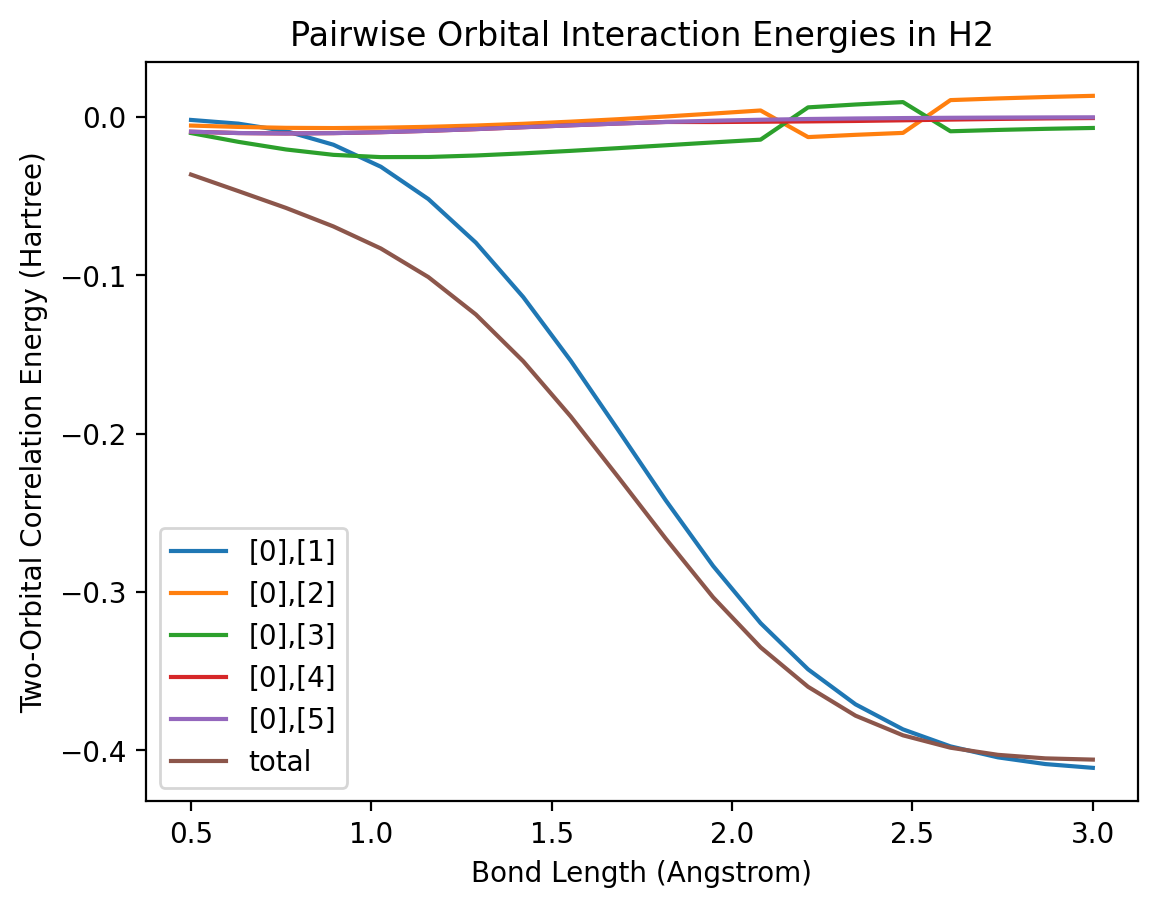

In [32]:
import matplotlib.pyplot as plt

total_mce = [mce_list_1[i] + mce_list_2[i] + mce_list_3[i] + mce_list_4[i] + mce_list_5[i] for i in range(0,len(mce_list_1))]

plt.plot(r_list, mce_list_1, label="[0],[1]")
plt.plot(r_list, mce_list_2, label="[0],[2]")
plt.plot(r_list, mce_list_3, label="[0],[3]")
plt.plot(r_list, mce_list_4, label="[0],[4]")
plt.plot(r_list, mce_list_5, label="[0],[5]")
plt.plot(r_list, total_mce, label="total")
plt.legend()
plt.xlabel("Bond Length (Angstrom)")
plt.ylabel("Two-Orbital Correlation Energy (Hartree)")
plt.title("Pairwise Orbital Interaction Energies in H2")

Text(0.5, 1.0, 'Absolute Pairwise Orbital Interaction Energies in H2')

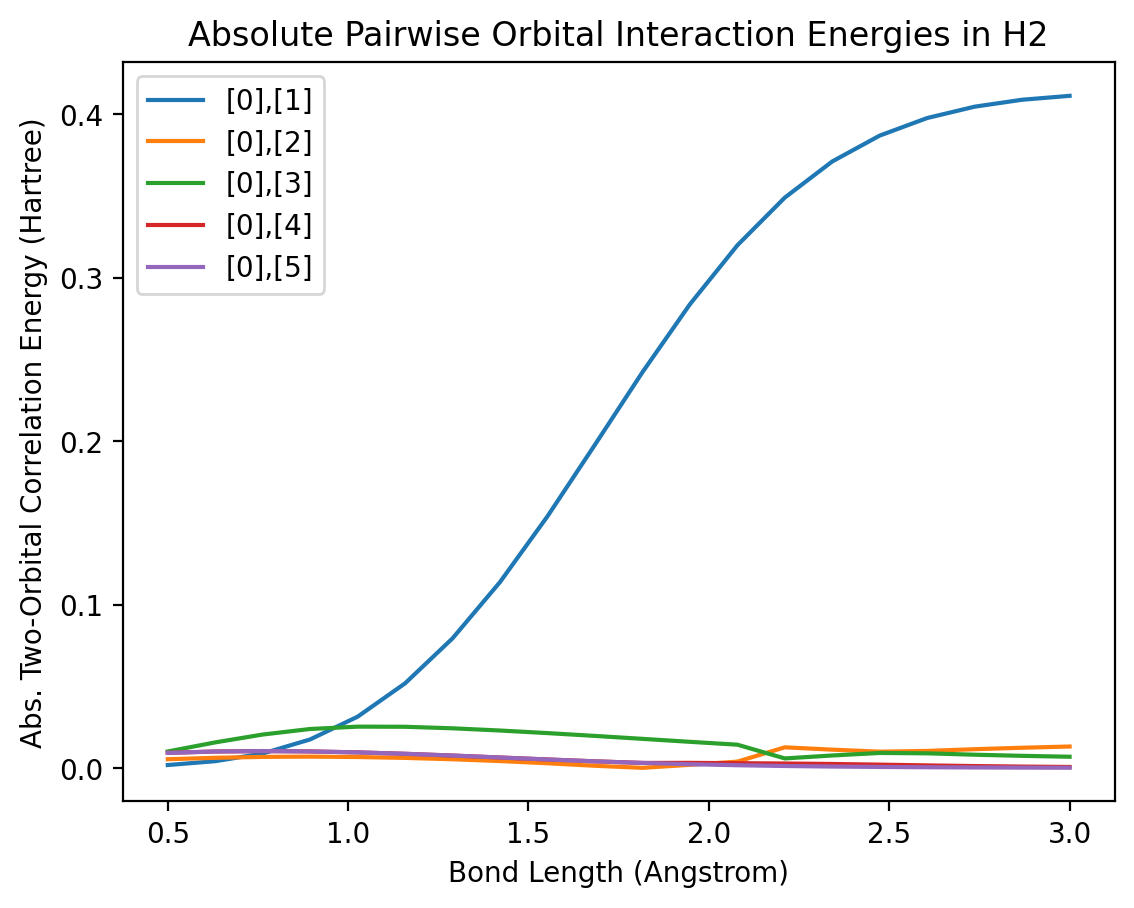

In [33]:
abs_mce_1 = [abs(mce_list_1[i]) for i in range(0,len(mce_list_1))]
abs_mce_2 = [abs(mce_list_2[i]) for i in range(0,len(mce_list_2))]
abs_mce_3 = [abs(mce_list_3[i]) for i in range(0,len(mce_list_3))]
abs_mce_4 = [abs(mce_list_4[i]) for i in range(0,len(mce_list_4))]
abs_mce_5 = [abs(mce_list_5[i]) for i in range(0,len(mce_list_5))]
abs_total_mce = [abs_mce_1[i] + abs_mce_2[i] + abs_mce_3[i] + abs_mce_4[i] + abs_mce_5[i] for i in range(0,len(abs_mce_1))]


plt.plot(r_list, abs_mce_1, label="[0],[1]")
plt.plot(r_list, abs_mce_2, label="[0],[2]")
plt.plot(r_list, abs_mce_3, label="[0],[3]")
plt.plot(r_list, abs_mce_4, label="[0],[4]")
plt.plot(r_list, abs_mce_5, label="[0],[5]")
#plt.plot(r_list, abs_total_mce, label="total")
plt.legend()
plt.xlabel("Bond Length (Angstrom)")
plt.ylabel("Abs. Two-Orbital Correlation Energy (Hartree)")
plt.title("Absolute Pairwise Orbital Interaction Energies in H2")


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   1.39839733   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.217e+00
  Min eigenvalue: 1.591e-03
  Condition number: 2.650e+03
  Inverse condition number: 3.774e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.591e-03
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:

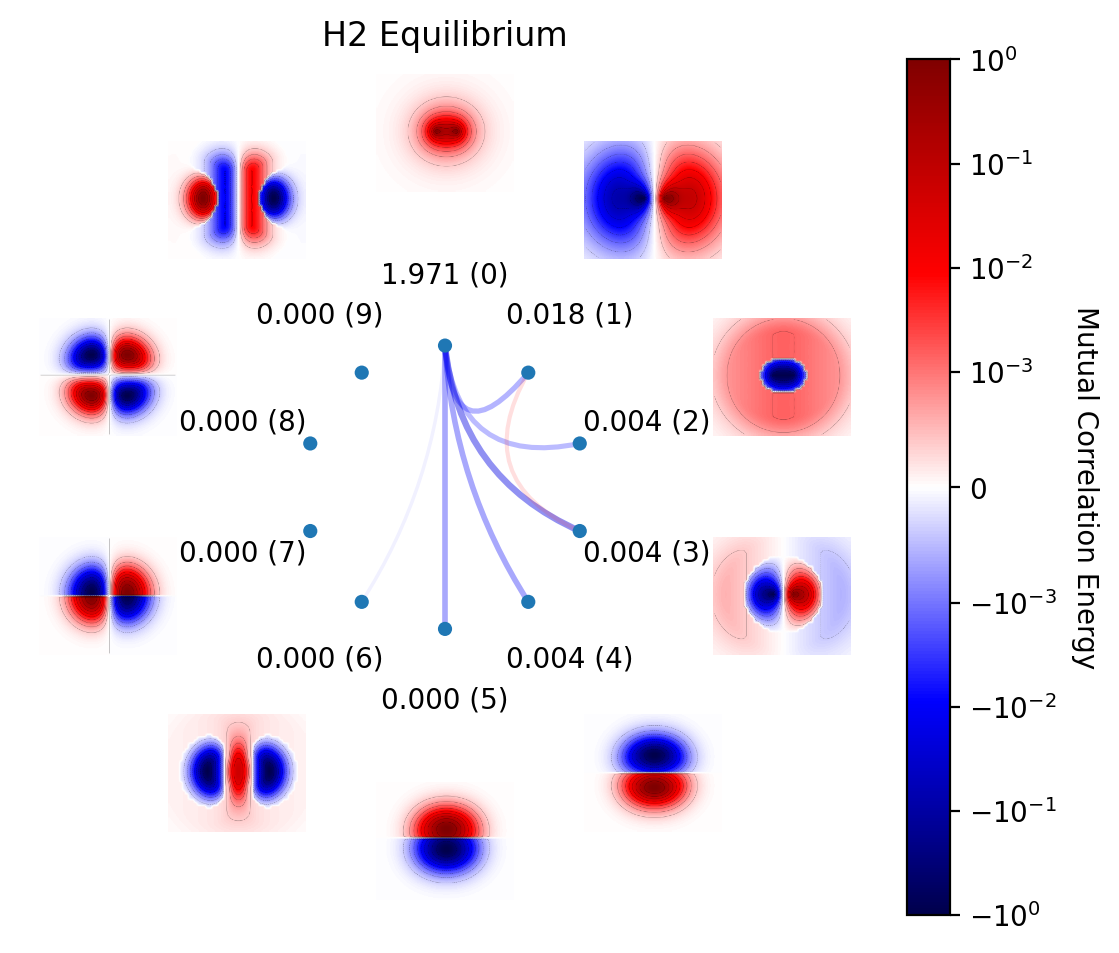

In [34]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.740 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

orb_list = hci.active_indices

# MCEmat = np.zeros((len(orb_list),len(orb_list)))
# for i in orb_list:
#     for j in orb_list:
#         if i != j: 
#             MCEmat[i,j] = mc_mod.twofrag_correlation_energy_enumerated(ci=hci,A_orbs=[i],B_orbs=[j])

mca = mc_mod.MutualCorrelationEnergyAnalysis(hci)

mutual_correlation_plot(system,hci.C[0],
                        indices=hci.active_indices,
                        mca=mca,
                        title="H2 Equilibrium",
                        occupation_numbers=hci.nat_occs
                        )
        

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   5.66917837   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 2.390e+00
  Min eigenvalue: 9.255e-02
  Condition number: 2.582e+01
  Inverse condition number: 3.872e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 9.255e-02
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:

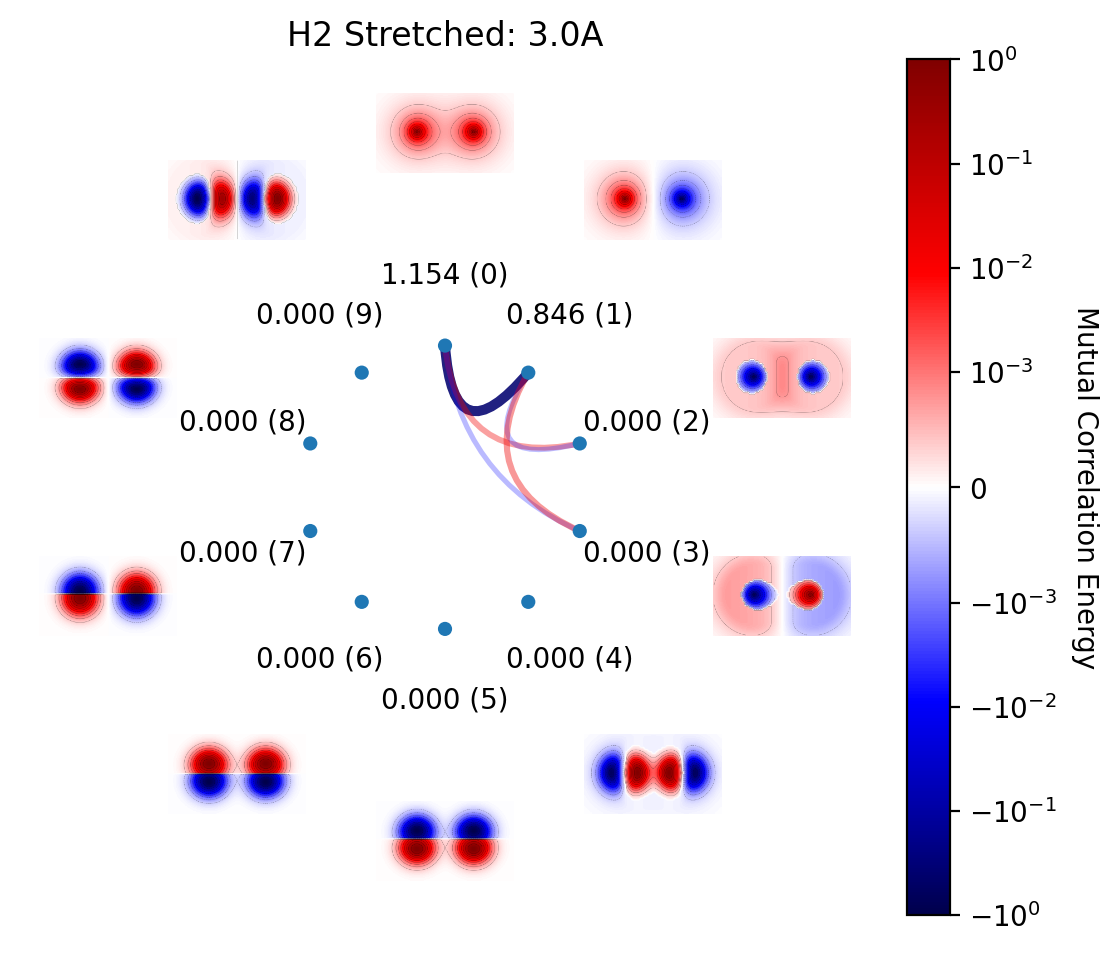

In [36]:
xyz = """
H 0.000 0.000 0.000
H 0.000 3.000 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

orb_list = hci.active_indices

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(hci)

mutual_correlation_plot(system,hci.C[0],
                        indices=hci.mo_space.active_indices,
                        mca=MCEmat,
                        title="H2 Stretched: 3.0A",
                        occupation_numbers=hci.nat_occs
                        )

### Some small organic systems

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   -1.74610524
   C   -2.30435717   0.00000000   -0.33782880
   C   -2.29240049   0.00000000   2.28226495
   C   0.00000000   0.00000000   3.61804507
   C   2.29240049   0.00000000   2.28226495
   C   2.30435717   0.00000000   -0.33782880
   H   -4.09358142   0.00000000   -1.36587798
   H   -4.07908326   0.00000000   3.31241362
   H   0.00000000   0.00000000   5.67867047
   H   4.07908326   0.00000000   3.31241362
   H   4.09358142   0.00000000   -1.36587798
   C   0.00000000   0.00000000   -4.40254673
   H   -1.76343138   0.00000000   -5.46500348
   H   1.76343138   0.00000000   -5.46500348
Parsed 14 atoms with basis set of 308 functions.
  Max eigenvalue: 8.077e+00
  Min eigenvalue: 3.538e-05
  Condition number: 2.283e+05
  Inverse condition number: 4.381e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 308
  Largest discarded ei

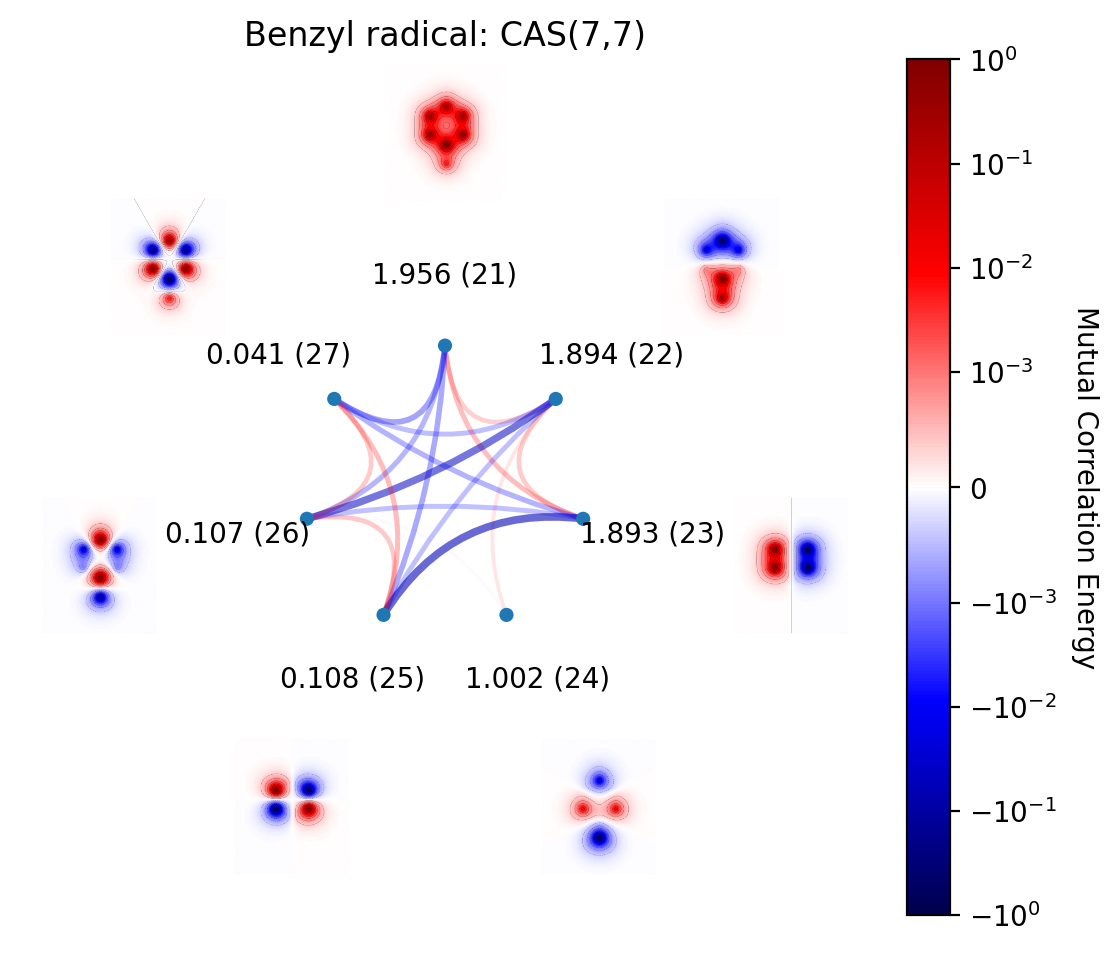

In [37]:
#benzyl radical
xyz="""
C 0.0000000 0.0000000 -0.9239991 
C -1.2194133 0.0000000 -0.1787713 
C -1.2130861 0.0000000 1.2077226 
C 0.0000000 0.0000000 1.9145870 
C 1.2130861 0.0000000 1.2077226 
C 1.2194133 0.0000000 -0.1787713 
H -2.1662300 0.0000000 -0.7227915 
H -2.1585579 0.0000000 1.7528538 
H 0.0000000 0.0000000 3.0050230 
H 2.1585579 0.0000000 1.7528538 
H 2.1662300 0.0000000 -0.7227915 
C 0.0000000 0.0000000 -2.3297274 
H -0.9331677 0.0000000 -2.8919553 
H 0.9331677 0.0000000 -2.8919553
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=0.5)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=2,ms=0.5))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Benzyl radical: CAS(7,7)",
                        occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        output_file="benzyl_radical"
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   -1.74610524
   C   -2.30435717   0.00000000   -0.33782880
   C   -2.29240049   0.00000000   2.28226495
   C   0.00000000   0.00000000   3.61804507
   C   2.29240049   0.00000000   2.28226495
   C   2.30435717   0.00000000   -0.33782880
   H   -4.09358142   0.00000000   -1.36587798
   H   -4.07908326   0.00000000   3.31241362
   H   0.00000000   0.00000000   5.67867047
   H   4.07908326   0.00000000   3.31241362
   H   4.09358142   0.00000000   -1.36587798
   C   0.00000000   0.00000000   -8.18199898
   H   -1.76343138   0.00000000   -9.24445573
   H   1.76343138   0.00000000   -9.24445573
Parsed 14 atoms with basis set of 308 functions.
  Max eigenvalue: 7.915e+00
  Min eigenvalue: 4.864e-05
  Condition number: 1.627e+05
  Inverse condition number: 6.145e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 308
  Largest discarded ei

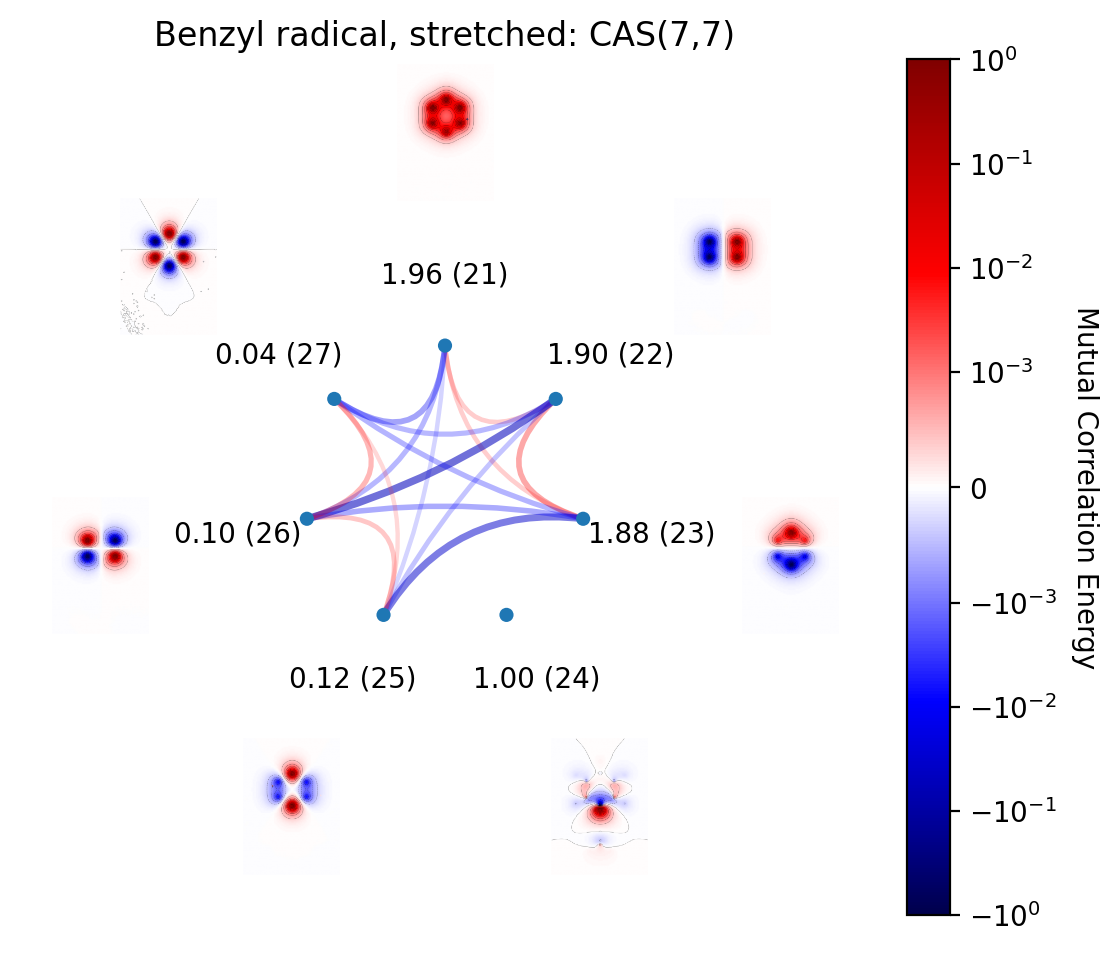

In [38]:
#benzyl radical w stretched bond
xyz="""
C 0.0000000 0.0000000 -0.9239991 
C -1.2194133 0.0000000 -0.1787713 
C -1.2130861 0.0000000 1.2077226 
C 0.0000000 0.0000000 1.9145870 
C 1.2130861 0.0000000 1.2077226 
C 1.2194133 0.0000000 -0.1787713 
H -2.1662300 0.0000000 -0.7227915 
H -2.1585579 0.0000000 1.7528538 
H 0.0000000 0.0000000 3.0050230 
H 2.1585579 0.0000000 1.7528538 
H 2.1662300 0.0000000 -0.7227915 
C 0.0000000 0.0000000 -4.3297274 
H -0.9331677 0.0000000 -4.8919553 
H 0.9331677 0.0000000 -4.8919553
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=0.5)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=2,ms=0.5))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Benzyl radical, stretched: CAS(7,7)",
                        #occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        output_file="benzyl_radical_stretched"
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   -1.78928661   0.00000000   -1.62750622
   C   -2.20560443   0.00000000   0.93494824
   C   0.00000000   0.00000000   2.41992243
   C   2.20560443   0.00000000   0.93494824
   C   1.78928661   0.00000000   -1.62750622
   C   0.00000000   0.00000000   -3.46812989
   H   -4.10446587   0.00000000   1.73494886
   H   0.00000000   0.00000000   4.48935867
   H   4.10446587   0.00000000   1.73494886
   H   0.00000000   0.00000000   -5.52593298
Parsed 10 atoms with basis set of 236 functions.
  Max eigenvalue: 8.024e+00
  Min eigenvalue: 6.965e-05
  Condition number: 1.152e+05
  Inverse condition number: 8.680e-06
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 236
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.965e-05
Number of electrons: 40
Number of alpha electrons: 20
Number of beta electrons: 20
Ms: 0.0
Total charge: 0
Number of basis f

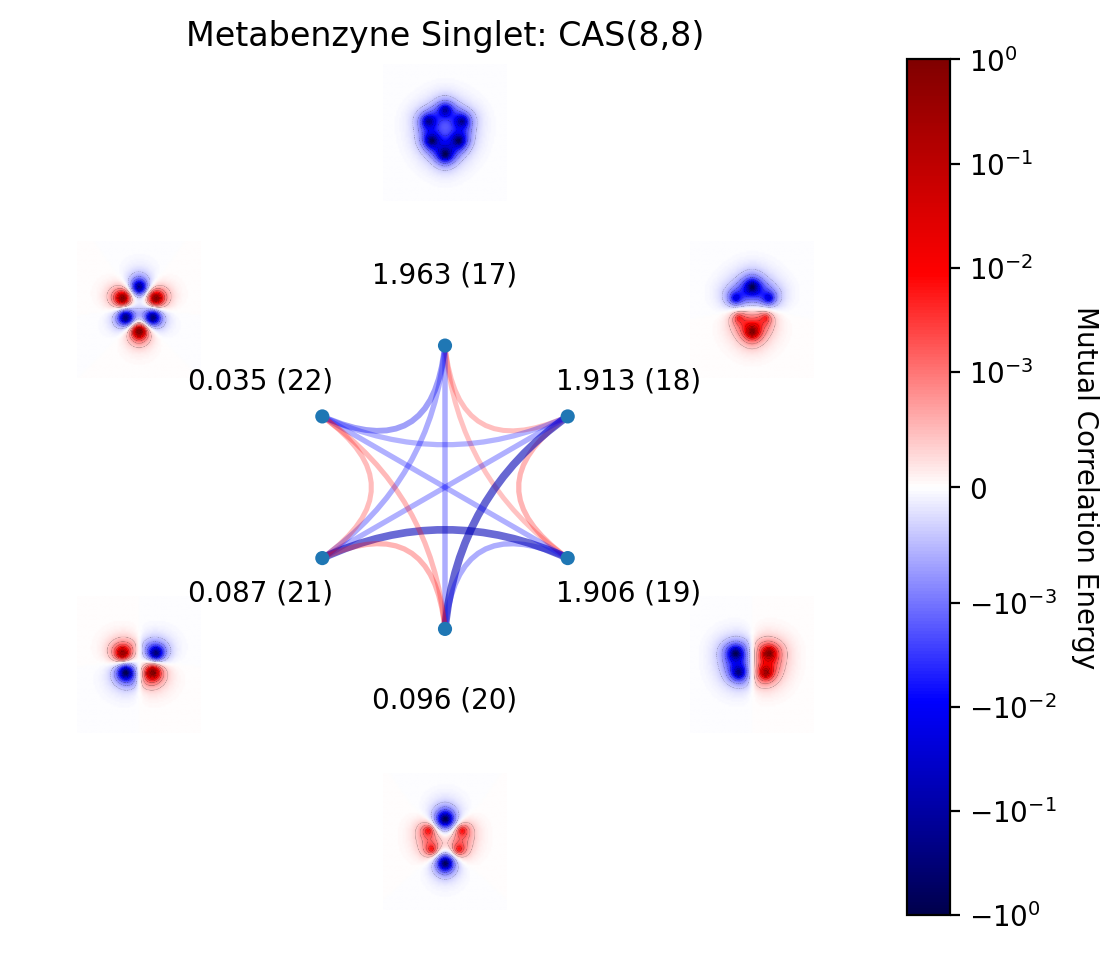

In [39]:
#metabenzyne
xyz="""
C -0.9468497 0.0000000 -0.8612392 
C -1.1671556 0.0000000 0.4947533 
C 0.0000000 0.0000000 1.2805678 
C 1.1671556 0.0000000 0.4947533 
C 0.9468497 0.0000000 -0.8612392 
C 0.0000000 0.0000000 -1.8352553 
H -2.1719898 0.0000000 0.9180954 
H 0.0000000 0.0000000 2.3756663 
H 2.1719898 0.0000000 0.9180954 
H 0.0000000 0.0000000 -2.9241978
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=0.0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='separate',
                   subspace=["C(2p)"],
                   num_active_docc=3,
                   num_active_uocc=3)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=1,ms=0.0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="Metabenzyne Singlet: CAS(8,8)",
                        occupation_numbers=ci.nat_occs,
                        projection_axis=1,
                        output_file="metabenzyne_singlet"
                        )

### TM Hydrides

In [40]:
xyz = """
Cu 0.000 0.000 0.000
H 0.000 1.463 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='total',
                   subspace=['Cu(3d)', 'Cu(4d)'],
                   num_active=10)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=1,ms=0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   CU   0.00000000   0.00000000   0.00000000
   H   0.00000000   2.76466932   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 4.664e+00
  Min eigenvalue: 6.738e-04
  Condition number: 6.922e+03
  Inverse condition number: 1.445e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.738e-04
Number of electrons: 30
Number of alpha electrons: 15
Number of beta electrons: 15
Ms: 0
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis funct

MCOptimizer(ci_solver=CISolver(states=State(multiplicity=1, ms=0, nel=30, system=System(atoms=[[29, array([0., 0., 0.])], [1, array([0.        , 2.76466932, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 82 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 282 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=15, nb=15, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=82, active_orbitals=[[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]], core_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=None, frozen_virtual_orbitals=None, die_if_not_converged=False, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e

In [41]:
orb_list=ci.active_indices
print(orb_list)

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)
print(MCEmat.mutual_correlation_matrix_summary())

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.0632007453

M2 Terms (|value| > 7.5e-04)
------------------------------------------
      11       16    -0.0234544152
      13       18    -0.0232363306
      14       15    -0.0164200189
      12       19    -0.0141934995
      10       17    -0.0137269800
      14       19    -0.0047052490
      10       15    -0.0043400527
      12       17    -0.0038959104
      10       14     0.0038805966
      11       14     0.0038805966
      12       13     0.0036736418
      11       15    -0.0032352534
      14       16    -0.0031337167
      14       17    -0.0030615343
      13       14     0.0029715149
      12       14     0.0029715149
      13       19    -0.0029669639
      12       18    -0.0029069608
      13       15    -0.0028524460
      12       15    -0.0028524459
      10       11     0.0028195901
      11       13     0.0027751112
      10       13     0.0027751112
      11


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 54 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]



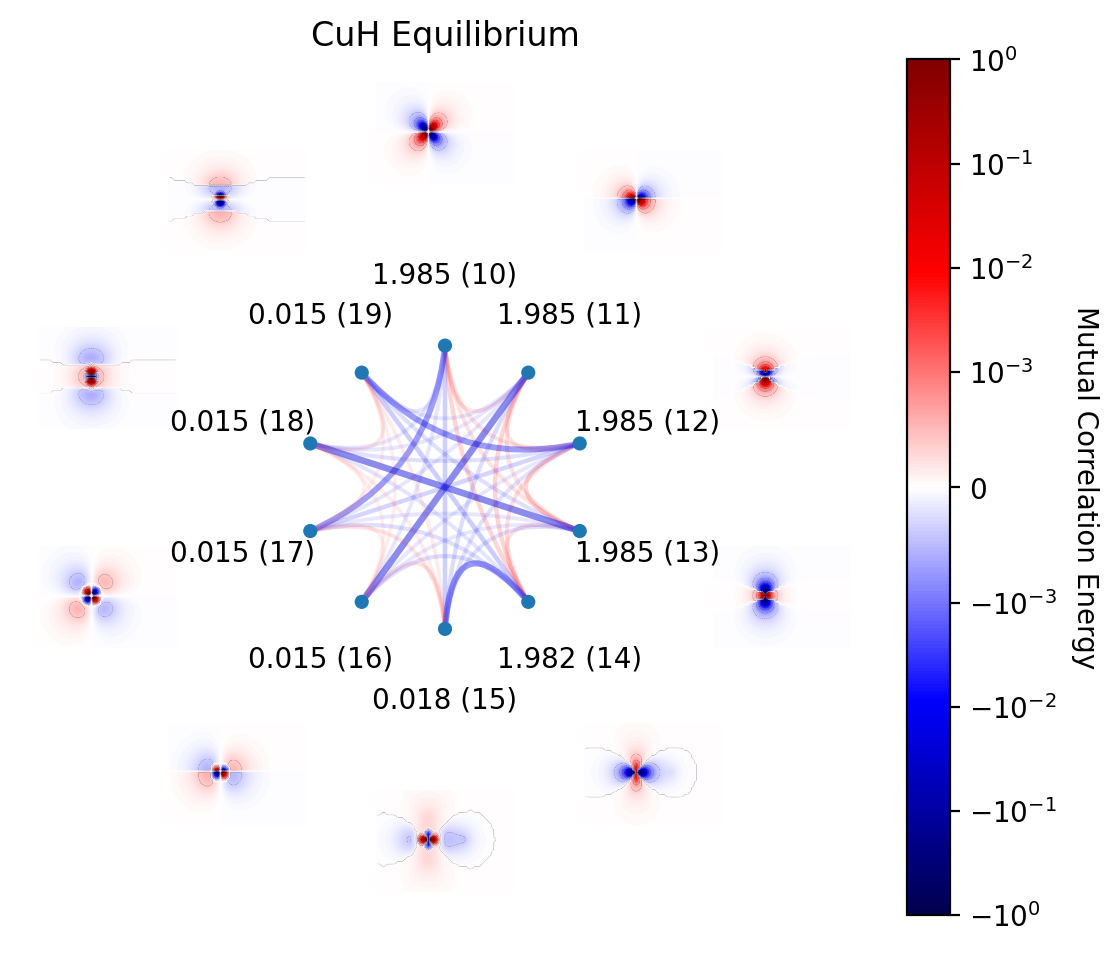

In [42]:
mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="CuH Equilibrium",
                        occupation_numbers=ci.nat_occs,
                        output_file="cuh_eq"
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   CU   0.00000000   0.00000000   0.00000000
   H   0.00000000   6.54412157   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 3.217e+00
  Min eigenvalue: 9.772e-04
  Condition number: 3.292e+03
  Inverse condition number: 3.037e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 9.772e-04
Number of electrons: 30
Number of alpha electrons: 15
Number of beta electrons: 15
Ms: 0
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis funct

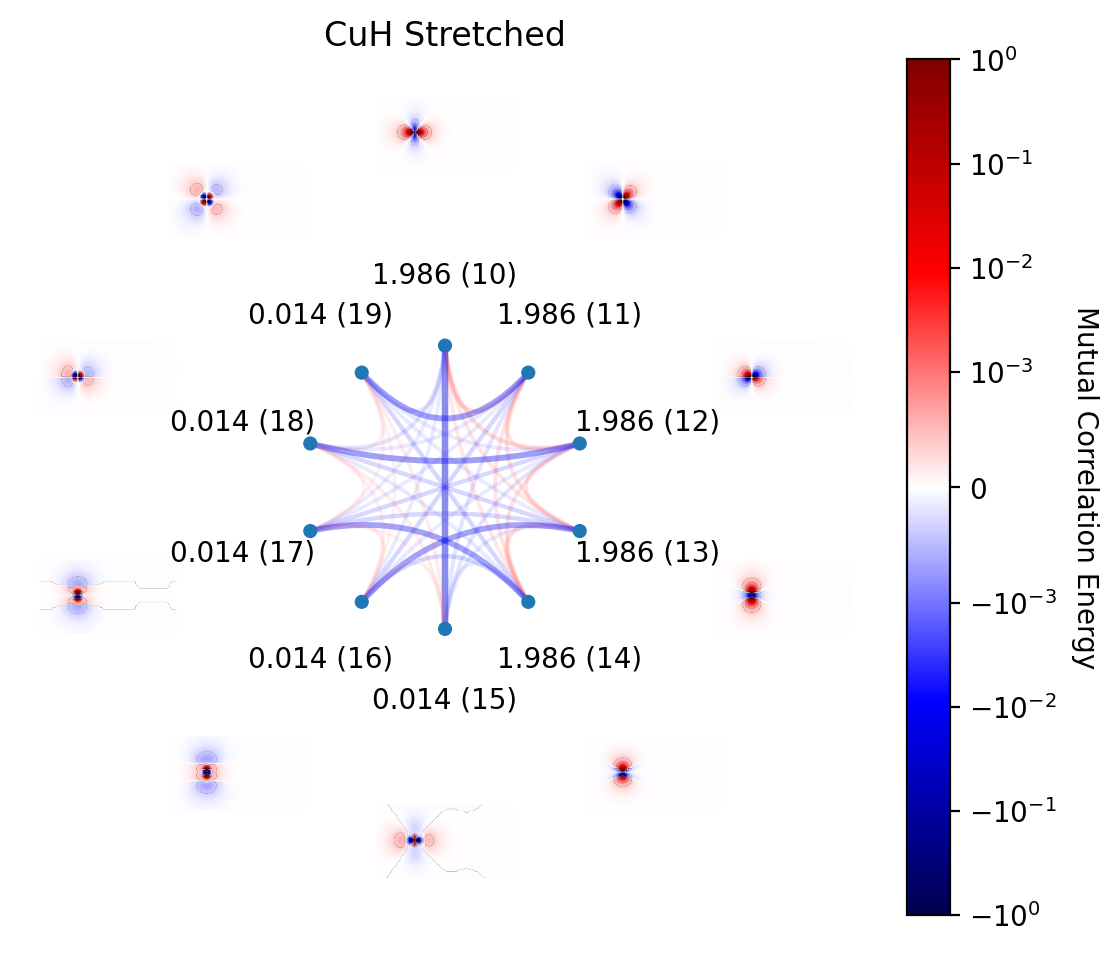

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.0775690752

M2 Terms (|value| > 7.5e-04)
------------------------------------------
      10       15    -0.0223223892
      12       18    -0.0134030925
      11       19    -0.0127503873
      14       17    -0.0119682668
      13       16    -0.0119555715
      11       16    -0.0037361565
      14       19    -0.0037306323
      13       17    -0.0037178099
      13       18    -0.0036308152
      12       17    -0.0036284733
      14       16    -0.0035979813
      13       14     0.0035426678
      10       11     0.0033039656
      10       12     0.0031785770
      12       14     0.0027197791
      11       12     0.0026566611
      12       13     0.0026564406
      11       13     0.0026550761
      11       15    -0.0026487750
      11       14     0.0026224387
      12       15    -0.0026036657
      10       18    -0.0026023702
      10       19    -0.0025915791
      10       13     0.0024283095
      10      

In [43]:
xyz = """
Cu 0.000 0.000 0.000
H 0.000 3.463 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

avas = forte2.AVAS(selection_method='total',
                   subspace=['Cu(3d)', 'Cu(4d)'],
                   num_active=10)(rhf)

ci=forte2.CISolver(forte2.State(system=system, multiplicity=1,ms=0))
mc=forte2.MCOptimizer(ci)(avas)
mc.run()

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="CuH Stretched",
                        occupation_numbers=ci.nat_occs,
                        output_file='cuh_stretched'
                        )

print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   NI   0.00000000   2.74766179   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 4.623e+00
  Min eigenvalue: 5.159e-04
  Condition number: 8.963e+03
  Inverse condition number: 1.116e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 5.159e-04
Number of electrons: 29
Number of alpha electrons: 15
Number of beta electrons: 14
Ms: 0.5
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis fu

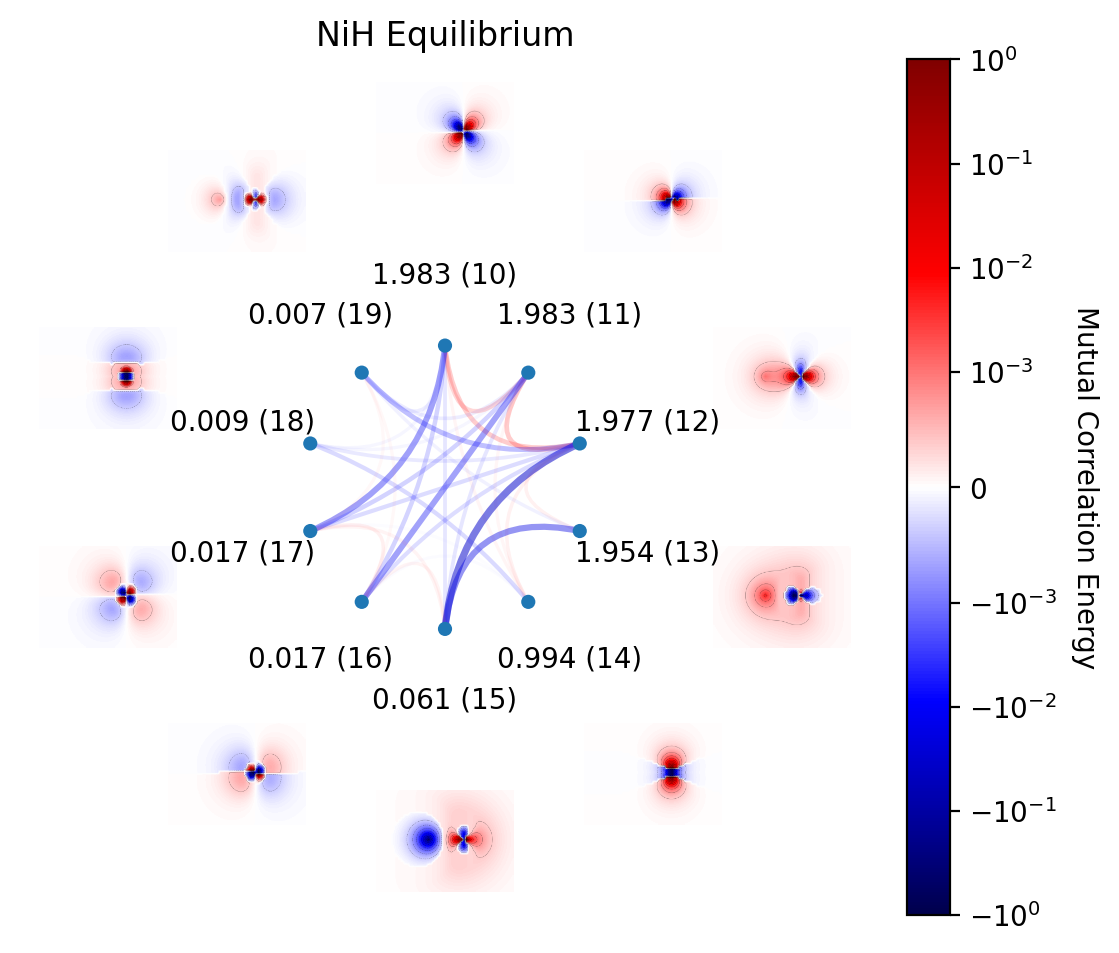

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.0725666739

M2 Terms (|value| > 7.5e-04)
------------------------------------------
      12       15    -0.0357868401
      13       15    -0.0174708820
      10       17    -0.0127217579
      11       16    -0.0125801536
      12       19    -0.0062089743
      11       12     0.0047870394
      10       12     0.0046362516
      11       17    -0.0040577258
      10       16    -0.0040204714
      10       11     0.0037116664
      14       18    -0.0033829501
      12       17    -0.0032119635
      12       16    -0.0031254428
      10       15    -0.0024269532
      11       15    -0.0024190153
      12       18    -0.0022562299
      11       19    -0.0019907283
      10       19    -0.0019620553
      16       17     0.0018242724
      12       13     0.0017491240
      12       14     0.0017425653
      13       19    -0.0017182453
      15       17     0.0016058404
      15       16     0.0015979870
      10      

In [45]:
xyz = """
H 0.000 0.000 0.000
Ni 0.000 1.454 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")
scf = forte2.ROHF(charge=0,ms=0.5)(system)
scf.run()

avas = forte2.AVAS(subspace=["Ni(3d)","Ni(4d)"],
                    selection_method="total",
                    num_active=10)(scf)
    
ci = forte2.CISolver(forte2.State(nel=29, multiplicity=2, ms=0.5),
    active_orbitals=10,
    core_orbitals=10,
    )
mc = forte2.MCOptimizer(ci,maxiter=100)(avas)
mc.run()

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="NiH Equilibrium",
                        occupation_numbers=ci.nat_occs,
                        output_file='nih_eq'
                        )
print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   NI   0.00000000   6.52711403   0.00000000
Parsed 2 atoms with basis set of 82 functions.
  Max eigenvalue: 3.160e+00
  Min eigenvalue: 8.763e-04
  Condition number: 3.607e+03
  Inverse condition number: 2.773e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 82
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.763e-04
Number of electrons: 29
Number of alpha electrons: 15
Number of beta electrons: 14
Ms: 0.5
Total charge: 0
Number of basis functions: 82
Number of orthogonalized basis functions: 82
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.03 GB (doubled due to storing B_nPm)
Number of system basis functions: 82
Number of auxiliary basis fu

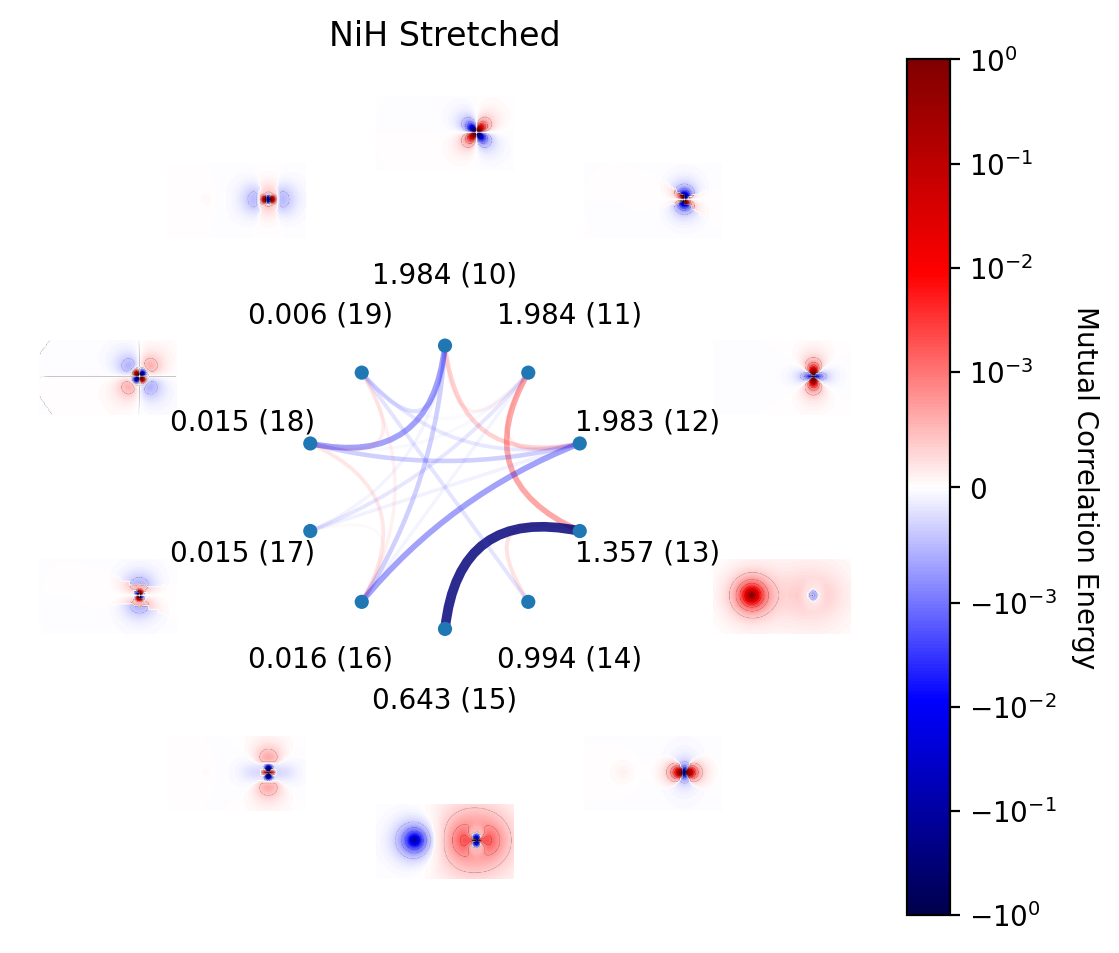

In [ ]:
xyz = """
H 0.000 0.000 0.000
Ni 0.000 3.454 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")
scf = forte2.ROHF(charge=0,ms=0.5)(system)
scf.run()

avas = forte2.AVAS(subspace=["Ni(3d)","Ni(4d)"],
                    selection_method="total",
                    num_active=10)(scf)
    
ci = forte2.CISolver(forte2.State(nel=29, multiplicity=2, ms=0.5),
    active_orbitals=10,
    core_orbitals=10,
    )
mc = forte2.MCOptimizer(ci,maxiter=100)(avas)
mc.run()

orb_list=ci.active_indices
print(orb_list)

MCEmat = mc_mod.MutualCorrelationEnergyAnalysis(ci)

mutual_correlation_plot(system,mc.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="NiH Stretched",
                        occupation_numbers=ci.nat_occs,
                        output_file="nih_stretched"
                        )

print(MCEmat.mutual_correlation_matrix_summary())